In [4]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)

In [5]:
stops = pd.read_csv('data/stops.txt')
stops.head()

,stop_id,stop_code,stop_name,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding,intersection_code,reference_place,stop_name_short,stop_place
0,11tbro,NaN,11th Ave & Broadway,32.716268,-117.154649,NaN,NaN,1,NaN,0,NaN,NaN,11tbro,NaN
1,12tS,NaN,12th & Imperial Station,32.706002,-117.153378,NaN,NaN,1,NaN,0,NaN,NaN,12tS,NaN
2,imtS,NaN,12th & Imperial Station Bayside,32.705229,-117.154318,NaN,NaN,1,NaN,0,NaN,NaN,imtS,NaN
3,imp12,NaN,12th & Imperial Transit Center,32.705685,-117.152875,NaN,NaN,1,NaN,0,NaN,NaN,imp12,NaN
4,24tS,NaN,24th Street Station,32.661854,-117.108017,NaN,NaN,1,NaN,0,NaN,NaN,24tS,NaN


In [6]:
print("Total stops:", len(stops))
print("\nMissing values per column:")
print(stops.isnull().sum())
print("\nDuplicate rows:", stops.duplicated().sum())
print("\nLat range:", stops['stop_lat'].min(), "to", stops['stop_lat'].max())
print("Lon range:", stops['stop_lon'].min(), "to", stops['stop_lon'].max())

Total stops: 4373

Missing values per column:
stop_id                   0
stop_code               103
stop_name                 0
stop_lat                  0
stop_lon                  0
zone_id                4373
stop_url               4373
location_type             0
parent_station         4112
wheelchair_boarding       0
intersection_code       227
reference_place        4352
stop_name_short           0
stop_place             3160
dtype: int64

Duplicate rows: 0

Lat range: 32.54281914 to 33.2568868
Lon range: -117.27792366 to -116.18445788


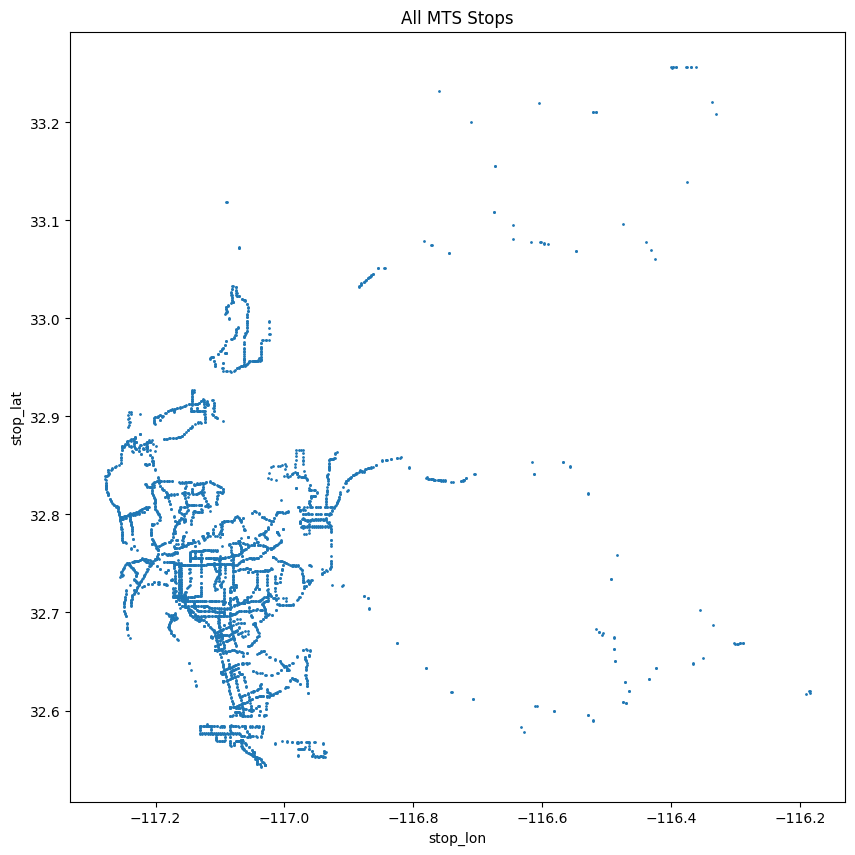

In [7]:
stops.plot.scatter(x='stop_lon', y='stop_lat', s=1, figsize=(10, 10))
plt.title('All MTS Stops')
plt.show()

## Observations: stops.txt
- 4,373 total stops
- All have valid stop_id, stop_name, lat, and lon (no missing) 
- Several columns are entirely empty (zone_id, stop_url) — drop 
- parent_station 94% missing —  applies to multi-platform stations
- 0 duplicate rows
- Coordinates within San Diego County bounds

In [8]:
routes = pd.read_csv('data/routes.txt')
routes.head()

,route_id,agency_id,route_short_name,route_long_name,route_type,route_url,route_color,route_text_color,route_group,route_pattern1,route_pattern2
0,1,MTS,1,Fashion Valley - La Mesa,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SBMF,1-W,1-E
1,2,MTS,2,Downtown San Diego - 30th & Adams,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SDTC,2-S1,2-N1
2,3,MTS,3,UCSD Hospital - Euclid Transit Center,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SBMF,3-N,3-S
3,4,MTS,4,12th & Imperial Trolley - Lomita Village,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SDTC,4-E,4-W
4,5,MTS,5,Downtown San Diego - Euclid Transit Center,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SBMF,5-E,5-W


In [9]:
print("Total routes:", len(routes))
print("\nMissing values:")
print(routes.isnull().sum())
print("\nDuplicates:", routes.duplicated().sum())

Total routes: 105

Missing values:
route_id             0
agency_id            0
route_short_name     2
route_long_name      0
route_type           0
route_url            0
route_color          0
route_text_color     0
route_group         10
route_pattern1       2
route_pattern2      21
dtype: int64

Duplicates: 0


In [10]:
ped = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/data/pedestrians.csv')
ped.head()

,timestamp,locationuid,direction,speed,count
0,2018-11-01 08:00:00,004361eb,165,2.641,1
1,2018-11-01 09:15:00,004361eb,165,2.641,1
2,2018-11-01 11:45:00,004361eb,165,2.641,1
3,2018-11-01 11:45:00,004361eb,345,2.641,1
4,2018-11-01 12:45:00,004361eb,165,2.641,1


In [11]:
print("Total rows:", len(ped))
print("\nMissing:")
print(ped.isnull().sum())
print("\nDuplicates:", ped.duplicated().sum())
print("\nSummary:")
ped.describe()

Total rows: 31502953

Missing:
timestamp      0
locationuid    0
direction      0
speed          0
count          0
dtype: int64

Duplicates: 0

Summary:


,direction,speed,count
count,3.150295e+07,3.150295e+07,3.150295e+07
mean,1.834278e+02,2.026961e+00,4.593354e+00
std,1.094149e+02,8.857956e-01,8.388960e+00
min,-1.000000e+00,0.000000e+00,1.000000e+00
25%,9.000000e+01,1.494250e+00,1.000000e+00
50%,1.800000e+02,2.247167e+00,2.000000e+00
75%,2.700000e+02,2.641000e+00,5.000000e+00
max,3.600000e+02,1.492023e+02,1.190000e+03


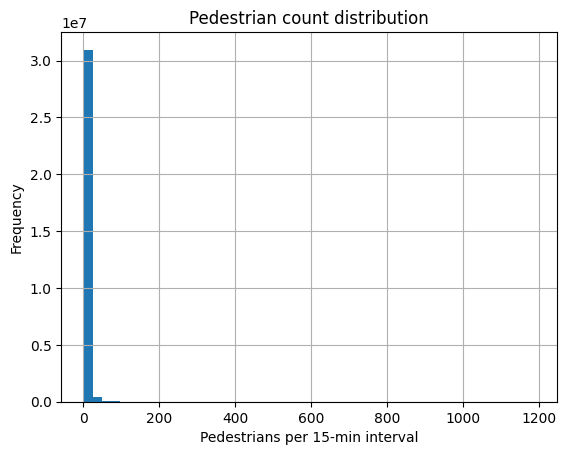

In [12]:
ped['count'].hist(bins=50)
plt.title('Pedestrian count distribution')
plt.xlabel('Pedestrians per 15-min interval')
plt.ylabel('Frequency')
plt.show()

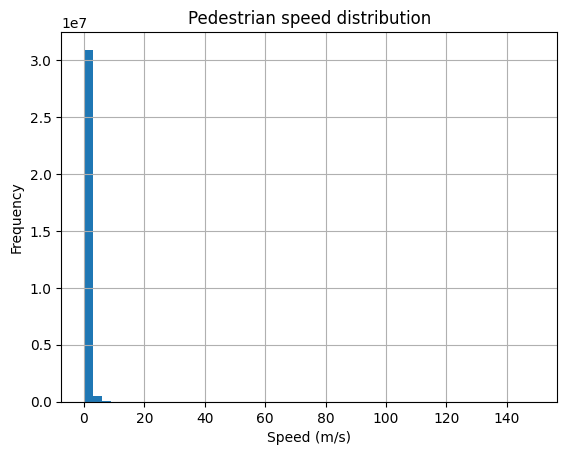

In [13]:
ped['speed'].hist(bins=50)
plt.title('Pedestrian speed distribution')
plt.xlabel('Speed (m/s)')
plt.ylabel('Frequency')
plt.show()

In [14]:
print("Rows with direction = -1:", (ped['direction'] == -1).sum())
print("Rows with speed > 10 m/s (faster than running):", (ped['speed'] > 10).sum())
print("Rows with count > 100 pedestrians:", (ped['count'] > 100).sum())

Rows with direction = -1: 30657
Rows with speed > 10 m/s (faster than running): 17949
Rows with count > 100 pedestrians: 33132


In [15]:
routes.head()

,route_id,agency_id,route_short_name,route_long_name,route_type,route_url,route_color,route_text_color,route_group,route_pattern1,route_pattern2
0,1,MTS,1,Fashion Valley - La Mesa,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SBMF,1-W,1-E
1,2,MTS,2,Downtown San Diego - 30th & Adams,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SDTC,2-S1,2-N1
2,3,MTS,3,UCSD Hospital - Euclid Transit Center,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SBMF,3-N,3-S
3,4,MTS,4,12th & Imperial Trolley - Lomita Village,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SDTC,4-E,4-W
4,5,MTS,5,Downtown San Diego - Euclid Transit Center,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SBMF,5-E,5-W


In [16]:
print("Total routes:", len(routes))
print(routes['route_type'].value_counts())

Total routes: 105
route_type
3    99
0     5
4     1
Name: count, dtype: int64


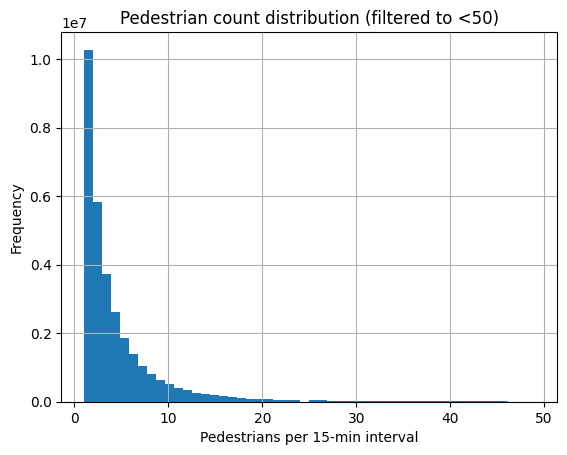

In [17]:
# Filter out the extreme outliers for a cleaner view
ped[ped['count'] < 50]['count'].hist(bins=50)
plt.title('Pedestrian count distribution (filtered to <50)')
plt.xlabel('Pedestrians per 15-min interval')
plt.ylabel('Frequency')
plt.show()

In [18]:
print("--- Pedestrian Count Distribution ---")
print(ped['count'].describe())
print(f"\nSkewness: {ped['count'].skew():.2f}  (>1 = heavily right-skewed)")
print(f"% of rows with count == 1:  {(ped['count']==1).mean()*100:.1f}%")
print(f"% of rows with count <= 2:  {(ped['count']<=2).mean()*100:.1f}%")

print("\n--- Anomaly Flags ---")
print(f"Rows with direction == -1 (invalid):           {(ped['direction']==-1).sum():,}")
print(f"Rows with speed > 10 m/s (impossible walking): {(ped['speed']>10).sum():,}")
print(f"Rows with count > 100 (likely event days):     {(ped['count']>100).sum():,}")
total = len(ped)
flagged = ((ped['direction']==-1) | (ped['speed']>10) | (ped['count']>100)).sum()
print(f"Total flagged rows: {flagged:,} ({flagged/total*100:.2f}% of data)")

print("\n--- Walking Speed Distribution (after filtering >10 m/s outliers) ---")
normal_speeds = ped[ped['speed'] <= 10]['speed']
print(normal_speeds.describe())

print("\n--- Temporal Coverage ---")
print(f"Earliest timestamp: {ped['timestamp'].min()}")
print(f"Latest timestamp:   {ped['timestamp'].max()}")
print(f"Unique sensor locations: {ped['locationuid'].nunique():,}")

--- Pedestrian Count Distribution ---
count    3.150295e+07
mean     4.593354e+00
std      8.388960e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      1.190000e+03
Name: count, dtype: float64

Skewness: 14.61  (>1 = heavily right-skewed)
% of rows with count == 1:  32.6%
% of rows with count <= 2:  51.2%

--- Anomaly Flags ---
Rows with direction == -1 (invalid):           30,657
Rows with speed > 10 m/s (impossible walking): 17,949
Rows with count > 100 (likely event days):     33,132
Total flagged rows: 81,666 (0.26% of data)

--- Walking Speed Distribution (after filtering >10 m/s outliers) ---
count    3.148500e+07
mean     2.019612e+00
std      8.153096e-01
min      0.000000e+00
25%      1.492351e+00
50%      2.244834e+00
75%      2.641000e+00
max      9.999964e+00
Name: speed, dtype: float64

--- Temporal Coverage ---
Earliest timestamp: 2018-08-01 06:45:00
Latest timestamp:   2019-06-01 00:00:00
Unique sensor locations: 2,691


## CityIQ Pedestrian Data (Aug 2018 – Jun 2019)

**Datasets explored**
- pedestrians.csv: 31,502,953 rows x 5 cols - 15-min interval pedestrian counts per sensor
- segments.csv: 11,269 rows - street segment metadata for sensor locations
- 2,691 unique sensor locations covering ~10 months of data

**Data quality**
- 0 missing values across all columns
- 0.26% of rows flagged as anomalies (81,666 of 31.5M)
  - 30,657 rows with direction = -1 (sensor calibration errors)
  - 17,949 rows with speed > 10 m/s (impossible walking pace)
  - 33,132 rows with count > 100 (likely event days)
- Walking speeds cluster around 2.02 m/s (matches normal walking pace - sensor reliability confirmed)

**Distributions**
- Pedestrian counts extremely right-skewed (skewness = 14.61, far above Poisson)
- 32.6% of rows have count = 1
- 51.2% of rows have count <= 2 (most intervals are very quiet)
- Mean 4.6, median 2, max 1,190 (max likely concert/event days)
- Hourly traffic peaks arou

# SmartRoutes Week 1 EDA Summary

## Datasets explored
- MTS GTFS: 4,373 stops, 105 routes (99 bus, 5 trolley, 1 ferry)
- CityIQ Pedestrian Counts: 31.5M rows from Aug 2018 - Jun 2019

## Data quality
- All stops have valid lat/lon coordinates within San Diego bounds
- 0 duplicate rows in any dataset
- Pedestrian data has no missing values (rare for real-world data!)
- ~0.3% of pedestrian rows have anomalies (sensor glitches: speed >10 m/s, count >100)

## Distributions
- Pedestrian counts heavily right-skewed (Poisson-like)
- Most 15-min intervals: 0-2 pedestrians
- Mean 4.6, median 2, max 1,190 (likely event days or sensor errors)
- Walking speeds cluster around 2 m/s (normal walking pace)

## Next steps
- Cross-reference high-count locations with existing bus stops
- Investigate the 30,657 rows with direction = -1
- Pull MTS realtime API for delay patterns

In [19]:
census_path = 'data/san-diego-census-2017/'

census_df = pd.read_csv(census_path + 'San Diego.csv')
meta_df = pd.read_csv(census_path + 'metaindicator.csv')

print(f"Census Data Shape: {census_df.shape}")
print(f"Metadata Shape:    {meta_df.shape}")

print("\n--- Column Dictionary (first 10) ---")
display(meta_df.head(10))

print("\n--- Census Data Preview ---")
display(census_df.head())

Census Data Shape: (628, 21)
Metadata Shape:    (13, 5)

--- Column Dictionary (first 10) ---


,Unnamed: 0,var_id,label,concept,short_name
0,0,B25077_001E,Estimate!!Median value (dollars),MEDIAN VALUE (DOLLARS),median_house_value
1,1,B02001_002E,Estimate!!Total!!White alone,RACE,total_pop_white
2,2,B01003_001E,Estimate!!Total,TOTAL POPULATION,total_pop
3,3,B25003_003E,Estimate!!Total!!Renter occupied,TENURE,total_rented
4,4,B25001_001E,Estimate!!Total,HOUSING UNITS,total_housing_units
5,5,B09019_006E,Estimate!!Total!!In households!!In family hous...,HOUSEHOLD TYPE (INCLUDING LIVING ALONE) BY REL...,hh_female
6,6,B09019_001E,Estimate!!Total,HOUSEHOLD TYPE (INCLUDING LIVING ALONE) BY REL...,hh_total
7,7,B15003_002E,Estimate!!Total!!No schooling completed,EDUCATIONAL ATTAINMENT FOR THE POPULATION 25 Y...,total_bachelor
8,8,B25018_001E,Estimate!!Median number of rooms,MEDIAN NUMBER OF ROOMS,median_no_rooms
9,9,B19083_001E,Estimate!!Gini Index,GINI INDEX OF INCOME INEQUALITY,income_gini



--- Census Data Preview ---


,Unnamed: 0,GEOID,geometry,median_age,total_pop,total_pop_white,tt_work,hh_total,hh_female,total_bachelor,...,income_gini,total_housing_units,total_rented,median_no_rooms,median_house_value,NAME,state,county,tract,sub_30
0,0,6073007701,"POLYGON ((-13052014.93 3867748.53, -13051974.6...",31.9,4074.0,3737.0,2243.0,4074.0,301.0,0.0,...,0.4182,2394.0,1499.0,3.9,852000.0,"Census Tract 77.01, San Diego County, California",6,73,7701,False
1,1,6073008002,"POLYGON ((-13052206.51 3870188.93, -13052193.6...",37.0,2968.0,2677.0,1558.0,2968.0,296.0,0.0,...,0.4094,1117.0,345.0,5.5,893300.0,"Census Tract 80.02, San Diego County, California",6,73,8002,False
2,2,6073007903,"POLYGON ((-13051964.72 3869215.2, -13051923.76...",30.2,4660.0,4079.0,3100.0,4660.0,425.0,0.0,...,0.4528,2582.0,1713.0,3.8,423500.0,"Census Tract 79.03, San Diego County, California",6,73,7903,False
3,3,6073008364,"POLYGON ((-13050548.18 3875343.81, -13050522.3...",30.1,5811.0,3135.0,3169.0,5811.0,448.0,0.0,...,0.3986,2902.0,2090.0,3.7,601100.0,"Census Tract 83.64, San Diego County, California",6,73,8364,False
4,4,6073008305,"POLYGON ((-13051530.24 3879241.24, -13051529.9...",27.1,2002.0,1053.0,879.0,2002.0,152.0,0.0,...,0.4797,815.0,706.0,4.0,517900.0,"Census Tract 83.05, San Diego County, California",6,73,8305,False


In [20]:
print("--- Census Data Info ---")
census_df.info()

print("\n--- Missing Values (top 10 columns) ---")
missing = census_df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(10))

print("\n--- Statistical Summary ---")
display(census_df.describe())

print("\n--- Possible geographic ID columns ---")
id_candidates = [col for col in census_df.columns if any(
    key in col.lower() for key in ['geo', 'tract', 'fips', 'id'])]
print(id_candidates)

--- Census Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           628 non-null    int64  
 1   GEOID                628 non-null    int64  
 2   geometry             628 non-null    str    
 3   median_age           628 non-null    float64
 4   total_pop            628 non-null    float64
 5   total_pop_white      628 non-null    float64
 6   tt_work              628 non-null    float64
 7   hh_total             628 non-null    float64
 8   hh_female            628 non-null    float64
 9   total_bachelor       628 non-null    float64
 10  median_hh_income     628 non-null    float64
 11  income_gini          628 non-null    float64
 12  total_housing_units  628 non-null    float64
 13  total_rented         628 non-null    float64
 14  median_no_rooms      628 non-null    float64
 15  median_house_value   628 n

,Unnamed: 0,GEOID,median_age,total_pop,total_pop_white,tt_work,hh_total,hh_female,total_bachelor,median_hh_income,income_gini,total_housing_units,total_rented,median_no_rooms,median_house_value,state,county,tract
count,628.000000,6.280000e+02,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,6.280000e+02,628.0,628.0,628.000000
mean,313.500000,6.073014e+09,37.212620,5228.765924,3702.920382,2332.433121,5228.765924,547.920382,66.525478,75402.798712,0.410741,1904.248408,832.157643,5.142765,5.155709e+05,6.0,73.0,14114.000000
std,181.432265,3.947166e+04,7.473292,2882.336492,2038.164080,1404.572326,2882.336492,302.545443,74.102849,30463.047753,0.055711,951.031552,632.039961,1.084002,2.677185e+05,0.0,0.0,39471.655779
min,0.000000,6.073000e+09,16.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22614.000000,0.283000,0.000000,0.000000,2.300000,1.790000e+04,6.0,73.0,100.000000
25%,156.750000,6.073008e+09,32.400000,3684.750000,2556.250000,1609.250000,3684.750000,354.750000,13.000000,52725.500000,0.374475,1295.250000,373.250000,4.200000,3.592000e+05,6.0,73.0,8335.750000
50%,313.500000,6.073013e+09,36.200000,4820.000000,3372.000000,2161.000000,4820.000000,496.000000,41.000000,70189.500000,0.407500,1750.000000,698.000000,5.142765,4.544500e+05,6.0,73.0,13409.500000
75%,470.250000,6.073018e+09,41.300000,6218.500000,4622.250000,2843.750000,6218.500000,675.750000,97.250000,92343.750000,0.440550,2307.250000,1109.500000,5.900000,5.974000e+05,6.0,73.0,17701.250000
max,627.000000,6.073990e+09,72.500000,40402.000000,30455.000000,24143.000000,40402.000000,3180.000000,578.000000,191642.000000,0.666700,9145.000000,7146.000000,7.900000,2.000001e+06,6.0,73.0,990100.000000



--- Possible geographic ID columns ---
['GEOID', 'geometry', 'tract']


## San Diego Census 2017 (ACS)

**Datasets explored**
- San Diego.csv: 628 rows x 21 columns - economic, social, geographic per census tract
- metaindicator.csv: column dictionary for 13 key indicators

**Data quality**
- 628 tracts covered (matches San Diego County's expected count, sanity check passed)
- 0 missing values across all columns (cleaner than the pedestrian data)
- Tract IDs in GEOID column
- Geometry column included as WKT POLYGONs - no separate shapefile needed for mapping
- One labeling inconsistency: total_bachelor column has "No schooling completed" label, needs verification

**Distributions (key insights)**
- Population per tract: mean 5,228, median 4,820, max 40,402 (high variance suggests dense vs sparse zones)
- Median age: mean 37, range 16.5-72.5
- Income gini coefficient available per tract - useful for socioeconomic clustering

**Next steps**
- Verify CRS of geometry column (looks like Web Mercator / EPSG:3857 based on coordinate magnitudes)
- Spatial join census tracts with MTS stops to count stops per tract
- Cross-reference high pedestrian counts with high-population tracts
- Identify low-stop-density / high-population tracts as underserved candidates
- Investigate the total_bachelor column labeling issue